# **Implementasi Reduksi Dimensi PCA dan Fuzzy C-Means untuk Clustering Data**

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from skfuzzy.cluster import cmeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
!pip install scikit-fuzzy

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from skfuzzy.cluster import cmeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
file_path = "hasil_crowling.csv"
data = pd.read_csv(file_path)

data

,Judul,Tanggal,Ringkasan,Kategori
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...",16 Okt 2024 18:04,Dalam rekaman yang diunggah terlihat sopir tru...,Peristiwa
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...,16 Okt 2024 18:02,"Kabid Humas Polda Metro Jaya, Kombes Pol Ade A...",Peristiwa
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...,16 Okt 2024 16:05,Mulusnya transisi pemerintahan dapat menjaga s...,Politik
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...",16 Okt 2024 16:01,"Mantan Manajer Retail PT Antam, Nuning Septi W...",Peristiwa
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...,16 Okt 2024 16:00,Dewan Perwakilan Rakyat (DPR) RI telah menerim...,Peristiwa
5,"Pramono: Semua Ketum Parpol Teman Saya, Nanti ...",16 Okt 2024 15:51,"Calon Gubernur Jakarta, Pramono Anung mengaku ...",News
6,DPR Minta Herindra Bisa Netral saat Sudah Resm...,16 Okt 2024 15:41,"Kepada Herindra, Puan menitipkan pesan khusus ...",Peristiwa
7,"Pengamat Nilai Jika SK-ADT Pimpin Sulut, Dukun...",16 Okt 2024 15:25,Pengamat politik dan pemerintahan Sulawesi Uta...,Politik
8,"Cegah Banjir Terulang, Pramono Bakal Bebaskan ...",16 Okt 2024 15:22,Untuk mengatasi banjir di daerah bantaran kali...,News
9,Puan Maharani Masih Irit Bicara soal Pertemuan...,16 Okt 2024 15:03,"Ketua DPP PDI Perjuangan, Puan Maharani belum ...",Politik


In [ ]:
file_path = "hasil_crowling.csv"
data = pd.read_csv(file_path)

print(data.columns.tolist())

['Judul', 'Tanggal', 'Ringkasan', 'Kategori']


In [ ]:
import pandas as pd

In [ ]:
file_path = "hasil_crowling.csv"
data = pd.read_csv(file_path)

# Menampilkan nama kolom dalam baris terpisah setiap 20 kolom
column_names = data.columns.tolist()
for i in range(0, len(column_names), 20):
    print(", ".join(column_names[i:i+20]))

Judul, Tanggal, Ringkasan, Kategori


In [ ]:
labels = data['Kategori']
features = data.drop('Kategori', axis=1).values

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.6 MB/s eta 0:00:00


In [ ]:
from sklearn.decomposition import PCA
from skfuzzy.cluster import cmeans
from sklearn.metrics import accuracy_score
import numpy as np

# Contoh data
features = np.random.rand(100, 50)  # 100 sampel, 50 fitur
encoded_labels = np.random.randint(2, size=100)  # 100 label biner

results = {}

# Fuzzy C-Means Clustering dan PCA untuk dimensi yang berbeda
max_dim = min(features.shape[1], 100)

for dim in range(max_dim, 1, -1):
    # Kurangi dimensi data
    pca = PCA(n_components=dim)
    reduced_features = pca.fit_transform(features)

    # Fuzzy C-Means Clustering
    cntr, u, u0, d, jm, p, fpc = cmeans(
        data=reduced_features.T,
        c=2,                  # 2 clusters
        m=2.0,                # Tingkat fuzziness
        error=0.005,          # Toleransi error
        maxiter=1000          # Iterasi maksimum
    )

    # Keanggotaan cluster
    cluster_membership = np.argmax(u, axis=0)

    # Hitung akurasi berdasarkan label asli
    accuracy = max(
        accuracy_score(encoded_labels, cluster_membership),
        accuracy_score(encoded_labels, 1 - cluster_membership)  # Cek inversi cluster
    )

    # Simpan hasil
    results[dim] = {
        'pca_features': reduced_features,
        'centroids': cntr,
        'membership': cluster_membership,
        'accuracy': accuracy
    }


In [ ]:
best_dim = max(results, key=lambda dim: results[dim]['accuracy'])
best_accuracy = results[best_dim]['accuracy']

print(f"Akurasi terbaik: {best_accuracy:.2f} pada dimensi {best_dim}.")

Akurasi terbaik: 0.61 pada dimensi 2.


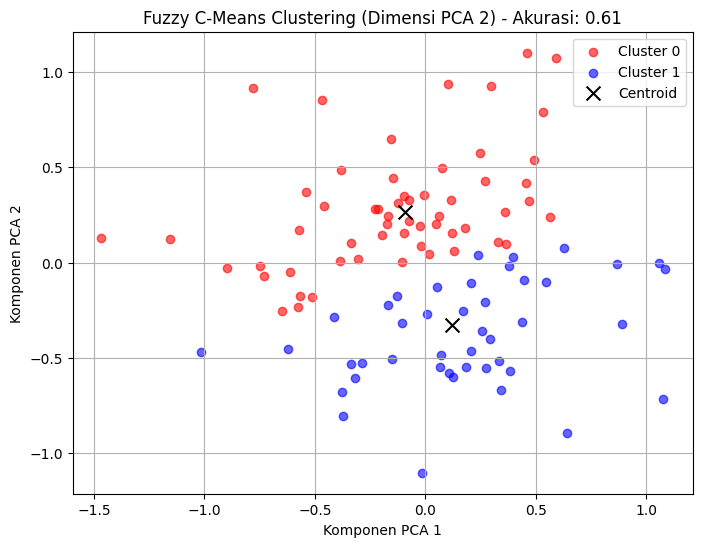

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot untuk dimensi terbaik (2 dimensi)
final_result = results[best_dim]
pca_features = final_result['pca_features']
centroids = final_result['centroids']
membership = final_result['membership']
accuracy = final_result['accuracy']

plt.figure(figsize=(8, 6))
colors = ['red', 'blue']
for i in range(2):  # Untuk 2 cluster
    cluster_points = pca_features[membership == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}', alpha=0.6)

# Tambahkan centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=100, label='Centroid')
plt.title(f"Fuzzy C-Means Clustering (Dimensi PCA {best_dim}) - Akurasi: {accuracy:.2f}")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend()
plt.grid()
plt.show()

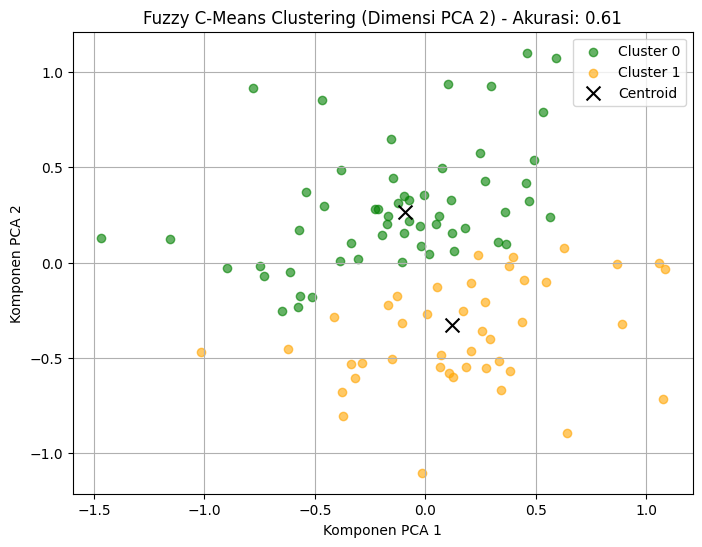

In [ ]:
final_result_2d = results[2]
pca_features_2d = final_result_2d['pca_features']
centroids_2d = final_result_2d['centroids']
membership_2d = final_result_2d['membership']
accuracy_2d = final_result_2d['accuracy']

# Scatter Plot untuk Dimensi 2
plt.figure(figsize=(8, 6))
colors = ['green', 'orange']
for i in range(2):  # Untuk 2 cluster
    cluster_points = pca_features_2d[membership_2d == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}', alpha=0.6)

# Tambahkan centroid
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', marker='x', s=100, label='Centroid')
plt.title(f"Fuzzy C-Means Clustering (Dimensi PCA 2) - Akurasi: {accuracy_2d:.2f}")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend()
plt.grid()
plt.show()

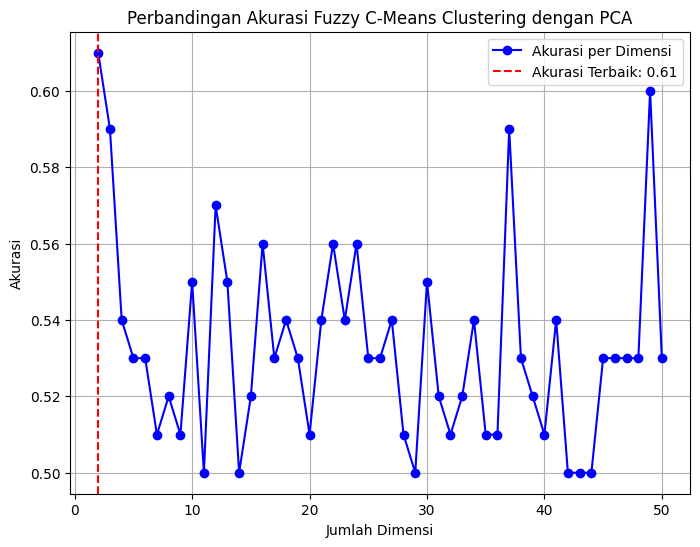

In [ ]:
dim_list = list(results.keys())
accuracy_list = [result['accuracy'] for result in results.values()]

plt.figure(figsize=(8, 6))
plt.plot(dim_list, accuracy_list, marker='o', color='b', linestyle='-', label="Akurasi per Dimensi")
plt.xlabel("Jumlah Dimensi")
plt.ylabel("Akurasi")
plt.title(f"Perbandingan Akurasi Fuzzy C-Means Clustering dengan PCA")
plt.axvline(best_dim, color='r', linestyle='--', label=f"Akurasi Terbaik: {best_accuracy:.2f}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for dim, result in results.items():
    print(f"Dimensi: {dim}, Akurasi: {result['accuracy']:.2f}")

Dimensi: 50, Akurasi: 0.53
Dimensi: 49, Akurasi: 0.60
Dimensi: 48, Akurasi: 0.53
Dimensi: 47, Akurasi: 0.53
Dimensi: 46, Akurasi: 0.53
Dimensi: 45, Akurasi: 0.53
Dimensi: 44, Akurasi: 0.50
Dimensi: 43, Akurasi: 0.50
Dimensi: 42, Akurasi: 0.50
Dimensi: 41, Akurasi: 0.54
Dimensi: 40, Akurasi: 0.51
Dimensi: 39, Akurasi: 0.52
Dimensi: 38, Akurasi: 0.53
Dimensi: 37, Akurasi: 0.59
Dimensi: 36, Akurasi: 0.51
Dimensi: 35, Akurasi: 0.51
Dimensi: 34, Akurasi: 0.54
Dimensi: 33, Akurasi: 0.52
Dimensi: 32, Akurasi: 0.51
Dimensi: 31, Akurasi: 0.52
Dimensi: 30, Akurasi: 0.55
Dimensi: 29, Akurasi: 0.50
Dimensi: 28, Akurasi: 0.51
Dimensi: 27, Akurasi: 0.54
Dimensi: 26, Akurasi: 0.53
Dimensi: 25, Akurasi: 0.53
Dimensi: 24, Akurasi: 0.56
Dimensi: 23, Akurasi: 0.54
Dimensi: 22, Akurasi: 0.56
Dimensi: 21, Akurasi: 0.54
Dimensi: 20, Akurasi: 0.51
Dimensi: 19, Akurasi: 0.53
Dimensi: 18, Akurasi: 0.54
Dimensi: 17, Akurasi: 0.53
Dimensi: 16, Akurasi: 0.56
Dimensi: 15, Akurasi: 0.52
Dimensi: 14, Akurasi: 0.50
D

Link Deployment : https://huggingface.co/spaces/22-065/ppwtugas9